In [2]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    'xtick.labelsize': 9,
	'ytick.labelsize': 9,
    "axes.labelsize": 10,
	'axes.titlesize': 10,
    'axes.grid': True,
	'figure.titlesize': 12,
	'legend.fontsize': 9,
	'legend.title_fontsize': 9,
	"figure.figsize": (4,3),
    "figure.autolayout": True,
    "savefig.dpi": 600,
    
})

Estimated polarizer extinction ratio: 0.1711
Estimated polarizer transmission ratio: 0.8289
[ 6.19194402 36.28567357 48.91458282 63.69159906]
[1.42449795 6.37483861 8.04247837 8.78061273]
[[Model]]
    Model(fitfunc)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 7
    # data points      = 4
    # variables        = 2
    chi-square         = 17.2011361
    reduced chi-square = 8.60056807
    Akaike info crit   = 9.83472430
    Bayesian info crit = 8.60731303
    R-squared          = 0.99536964
[[Variables]]
    A:  1246.44235 +/- 34.4592039 (2.76%) (init = 1000)
    C:  8.36861088 +/- 4.15704612 (49.67%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(A, C) = -0.2970
[[Model]]
    Model(<lambda>)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 4
    # variables        = 1
    chi-square         = 11270.0129
    reduced chi-square = 3756.67097
    Akaike info crit   = 33.774425

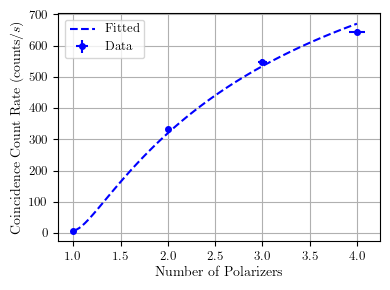

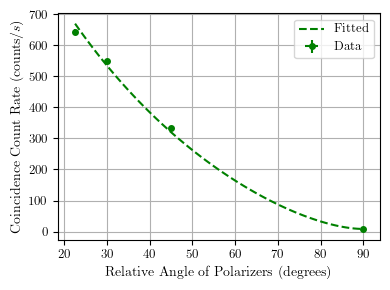

In [20]:
data = np.genfromtxt('data.csv', delimiter=',',skip_header=1)
n = np.array(data[:,0])

pol_transmission = 18340 / 22127
pol_extinction = 1 - pol_transmission

window = 40e-9 # coincidence window in seconds

print(f"Estimated polarizer extinction ratio: {pol_extinction:.4f}")
print(f"Estimated polarizer transmission ratio: {pol_transmission:.4f}")

# count rates in counts/second
single0 = np.array(data[:,1]) / 10
single1 = np.array(data[:,2]) / 10
coinc = np.array(data[:,3]) / 10
angles = 90 / n

single0err = np.sqrt(single0 * 10) / 10 # Poisson error for count rates
single1err = np.sqrt(single1 * 10) / 10
coincerr = np.sqrt(coinc * 10) / 10
angleserr = np.ones_like(angles) * 0.5 # Assuming 0.5 degree uncertainty in angle measurements
nerr = angleserr * n**2 / 90 # Propagate angle error to n

acc = window * single0 * single1
accerr = np.sqrt(acc * 10) / 10
print(acc)
coinc -= acc
coincerr = np.sqrt(coincerr**2 + accerr**2) # Combine errors in quadrature

# coinc -= coinc[0]
# coincerr = np.sqrt(coincerr**2 + coincerr[0]**2) # Combine errors in quadrature
print(coincerr)
max_coinc = np.max(coinc)

def fitfunc(x, A, C):
	return A * np.cos(np.radians(x))**(2*np.pi/(2*np.radians(x))) + C

model = Model(fitfunc)
params = Parameters()
params.add('A', value=1000)
# params.add('p', value=2)
params.add('C', value=0)
result = model.fit(coinc, params, x=angles, weights=1/coincerr)
print(result.fit_report())

angles_fit = np.linspace(angles.min(), angles.max(), 100)
coinc_fit = model.eval(result.params, x=angles_fit)

n_plot = n
n_fit = np.linspace(n_plot.min(), n_plot.max(), 100)
coinc_n_plot = coinc
fit_n_plot = model.eval(result.params, x=90 / n_fit)

model_null = Model(lambda x, A: A)
params_null = Parameters()
params_null.add('A', value=coinc[0])
result_null = model_null.fit(coinc, params_null, x=angles, weights=1/coincerr)
print(result_null.fit_report())

delta_chi2 = result_null.chisqr - result.chisqr
sigma = np.sqrt(delta_chi2)
print(f'Sigma: {sigma:.3f}')


plt.figure()
plt.errorbar(n_plot, coinc_n_plot, xerr=nerr, yerr=coincerr, fmt='bo', label='Data', markersize=4)
plt.plot(n_fit, fit_n_plot, 'b--', label='Fitted')
plt.xlabel('Number of Polarizers')
plt.ylabel(r'Coincidence Count Rate (counts/$s$)')
plt.legend()
plt.savefig('coincidence_vs_n.pdf')
plt.show()

plt.figure()
plt.errorbar(angles, coinc, xerr=angleserr, yerr=coincerr, fmt='go', label='Data', markersize=4)
plt.plot(angles_fit, coinc_fit, 'g--', label='Fitted')
plt.xlabel('Relative Angle of Polarizers (degrees)')
plt.ylabel(r'Coincidence Count Rate (counts/$s$)')
plt.legend()
plt.savefig('coincidence_vs_angles.pdf')
plt.show()

Estimated polarizer extinction ratio: 0.1711
Estimated polarizer transmission ratio: 0.8289
Beta: [1250.53194474    8.05867731]
Beta Std Error: [33.5718888   2.44365916]
Beta Covariance: [[265.52496557  -3.54435078]
 [ -3.54435078   1.40680878]]
Residual Variance: 4.244692075960539
Inverse Condition #: 0.011355603365131039
Reason(s) for Halting:
  Sum of squares convergence
Chi-square: 8.4894
Reduced chi-square: 4.2447
Degrees of freedom: 2
R^2: 0.9952
Beta (fit params): [1250.53194474    8.05867731]
Beta std errors: [33.5718888   2.44365916]


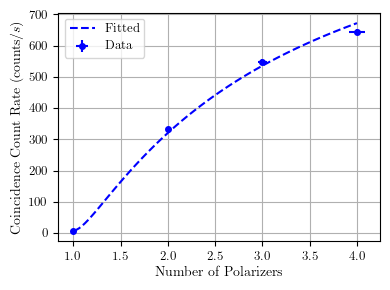

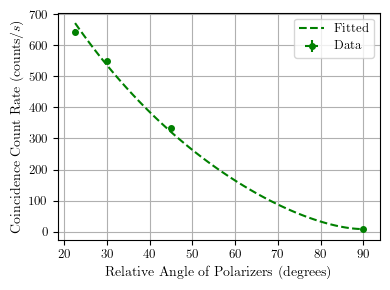

Slope: 224.839 ± 38.738 (5.80σ from zero)


In [39]:
data = np.genfromtxt('data.csv', delimiter=',',skip_header=1)
n = np.array(data[:,0])

pol_transmission = 18340 / 22127
pol_extinction = 1 - pol_transmission

window = 40e-9 # coincidence window in seconds

print(f"Estimated polarizer extinction ratio: {pol_extinction:.4f}")
print(f"Estimated polarizer transmission ratio: {pol_transmission:.4f}")

# count rates in counts/second
single0 = np.array(data[:,1]) / 10
single1 = np.array(data[:,2]) / 10
coinc = np.array(data[:,3]) / 10
angles = 90 / n

single0err = np.sqrt(single0 * 10) / 10 # Poisson error for count rates
single1err = np.sqrt(single1 * 10) / 10
coincerr = np.sqrt(coinc * 10) / 10
angleserr = np.ones_like(angles) * 0.5 # Assuming 0.5 degree uncertainty in angle measurements
nerr = angleserr * n**2 / 90 # Propagate angle error to n

acc = window * single0 * single1
accerr = acc * np.sqrt((single0err/single0)**2 + (single1err/single1)**2)
coinc -= acc
coincerr = np.sqrt(coincerr**2 + accerr**2) # Combine errors in quadrature


def fitfunc(beta, x):
	A, C = beta
	radx = np.radians(x)
	exp = 180/x
	return A * np.abs(np.cos(radx))**(exp) + C

from scipy.odr import ODR, Model, RealData
data = RealData(angles, coinc, sx=angleserr, sy=coincerr)
model = Model(fitfunc)
odr = ODR(data, model, beta0=[1200, 1])
result = odr.run()
result.pprint()

angles_fit = np.linspace(angles.min(), angles.max(), 100)
coinc_fit = fitfunc(result.beta, angles_fit)

n_plot = n
n_fit = np.linspace(n_plot.min(), n_plot.max(), 100)
coinc_n_plot = coinc
fit_n_plot = fitfunc(result.beta, 90/n_fit)

# Degrees of freedom = number of data points - number of fitted parameters
dof = len(angles) - len(result.beta)

# Reduced chi-square (ODR's "res_var" IS the reduced chi-square)
reduced_chi2 = result.res_var

# Chi-square (sum of squares of weighted residuals)
chi2 = reduced_chi2 * dof

# R^2 calculation
residuals = coinc - fitfunc(result.beta, angles)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((coinc - np.mean(coinc))**2)
r_squared = 1 - ss_res / ss_tot

print(f"Chi-square: {chi2:.4f}")
print(f"Reduced chi-square: {reduced_chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"R^2: {r_squared:.4f}")
print(f"Beta (fit params): {result.beta}")
print(f"Beta std errors: {result.sd_beta}")

# model_null = Model(lambda x, A: A)
# params_null = Parameters()
# params_null.add('A', value=coinc[0])
# result_null = model_null.fit(coinc, params_null, x=angles, weights=1/coincerr)
# print(result_null.fit_report())

# delta_chi2 = result_null.chisqr - result.chisqr
# sigma = np.sqrt(delta_chi2)
# print(f'Sigma: {sigma:.3f}')


plt.figure()
plt.errorbar(n_plot, coinc_n_plot, xerr=nerr, yerr=coincerr, fmt='bo', label='Data', markersize=4)
plt.plot(n_fit, fit_n_plot, 'b--', label='Fitted')
plt.xlabel('Number of Polarizers')
plt.ylabel(r'Coincidence Count Rate (counts/$s$)')
plt.legend()
plt.savefig('coincidence_vs_n.pdf')
plt.show()

plt.figure()
plt.errorbar(angles, coinc, xerr=angleserr, yerr=coincerr, fmt='go', label='Data', markersize=4)
plt.plot(angles_fit, coinc_fit, 'g--', label='Fitted')
plt.xlabel('Relative Angle of Polarizers (degrees)')
plt.ylabel(r'Coincidence Count Rate (counts/$s$)')
plt.legend()
plt.savefig('coincidence_vs_angles.pdf')
plt.show()



from scipy.odr import ODR, Model, RealData
linfunc = lambda beta, x: beta[0]*x + beta[1]
lindata = RealData(n, coinc, sy=coincerr)
linmodel = Model(linfunc)
linodr = ODR(lindata, linmodel, beta0=[1, coinc[0]])
linresult = linodr.run()
slope, intercept = linresult.beta
slope_err = linresult.sd_beta[0]
print(f"Slope: {slope:.3f} ± {slope_err:.3f} ({slope/slope_err:.2f}σ from zero)")